In [17]:
%matplotlib widget

In [ ]:
%pip install openpmd_viewer openpmd-api

/pscratch/sd/l/leosyam/diags/test


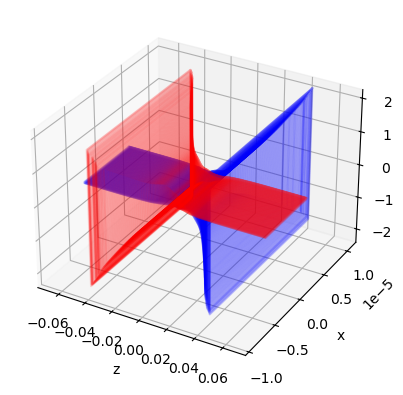

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import openpmd_viewer as ov
from openpmd_viewer import OpenPMDTimeSeries
import os

path = os.path.join(os.environ['PSCRATCH'], 'diags', 'test')
print(path)
ts_2d = OpenPMDTimeSeries(path)

def draw_plane(ax3d, cent, parvec, perpvec, width, height, color='black'):
  tl = cent + parvec * width/2 + perpvec * height/2
  tr = cent + parvec * width/2 - perpvec * height/2
  bl = cent - parvec * width/2 + perpvec * height/2
  br = cent - parvec * width/2 - perpvec * height/2
  pts = np.array([tl, tr, br, bl, tl])
  ax3d.plot(pts[:, 0], pts[:, 1], pts[:, 2], c=color)

time = ts_2d.t[0]
dt = 1e-12
steps = int(dt/(ts_2d.t[100] - ts_2d.t[99]))
finaltime = 4.3e-10
poses = np.empty(shape=(int((finaltime-time)/dt), 3))
means = np.empty(shape=(int((finaltime-time)/dt), 3))
times = np.empty(shape=(int((finaltime-time)/dt)))
i = 0
while time <= finaltime:
  pos = ts_2d.get_particle(species='test1', var_list=['x', 'y', 'z'], iteration=i*steps)
  mn = np.mean(pos, axis=1)
  pos = np.std(pos, axis=1)
  pos = np.array([[i for i in pos]])
  if len(poses) > i:
    poses[i] = pos
    means[i] = mn
    times[i] = time
  i += 1
  time = ts_2d.t[i * steps]

time = ts_2d.t[0]
poses2 = np.empty(shape=(int((finaltime-time)/dt), 3))
means2 = np.empty(shape=(int((finaltime-time)/dt), 3))
times2 = np.empty(shape=(int((finaltime-time)/dt)))
i = 0
while time <= finaltime:
  pos = ts_2d.get_particle(species='test2', var_list=['x', 'y', 'z'], iteration=i*steps)
  mn = np.mean(pos, axis=1)
  pos = np.std(pos, axis=1)
  pos = np.array([[i for i in pos]])
  if len(poses2) > i:
    poses2[i] = pos
    means2[i] = mn
    times2[i] = time
  i += 1
  time = ts_2d.t[i * steps]

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('z')
ax.set_ylabel('x')
ax.set_zlabel('y')

for i in range(len(poses)):
  stdevx, stdevy, z = poses[i]
  x, y, z = means[i]
  draw_plane(ax, np.array([z, x, y]), np.array([0, 1, 0]), np.array([0, 0, 1]), stdevx, stdevy, color=(0, 0, 1, 0.15))

for i in range(len(poses2)):
  stdevx, stdevy, z = poses2[i]
  x, y, z = means2[i]
  draw_plane(ax, np.array([z, x, y]), np.array([0, 1, 0]), np.array([0, 0, 1]), stdevx, stdevy, color=(1, 0, 0, 0.15))

plt.show()



